## Preprocessing 1

In [1]:
import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.metrics import accuracy_score, classification_report
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay)
import seaborn as sns

In [2]:
data = []
labels = []
file_name = []

path_dataset = "archive/tomato/train/"

target_classes = [
    "Tomato___Early_blight", 
    "Tomato___Septoria_leaf_spot", 
    "Tomato___healthy"
]

for sub_folder in target_classes:
    path_sub_folder = os.path.join(path_dataset, sub_folder)
    
    sub_folder_files = os.listdir(path_sub_folder)
    
    for i, filename in enumerate(sub_folder_files):
        img_path = os.path.join(path_sub_folder, filename)
        img = cv.imread(img_path)
        
        if img is not None:
            img = img.astype(np.uint8)
            
            data.append(img)
            labels.append(sub_folder)
            file_name.append(filename)
            
data = np.array(data, dtype=object)
labels = np.array(labels)

In [3]:
def ekualisasi_manual(image):
    hist, _ = np.histogram(image, 256, [0, 256])
    cdf = np.cumsum(hist)
    cdf_min = np.min(cdf)
    baris, kolom = image.shape
    total_pixel = baris * kolom

    if total_pixel == cdf_min:
        return np.zeros_like(image)
        
    cdf_normalized = np.round((cdf - cdf_min) * 255 / (total_pixel - cdf_min))
    
    hasil_eq = np.zeros_like(image)
    for i in range(baris):
        for j in range(kolom):
            hasil_eq[i, j] = cdf_normalized[int(image[i, j])]
            
    return hasil_eq


def median_filter_manual(img, size=3):
    height, width = img.shape
    pad = size // 2
    padded = np.pad(img, pad, mode='edge')
    canvas = np.zeros_like(img, dtype=np.uint8)
    
    for i in range(height):
        for j in range(width):
            region = padded[i:i+size, j:j+size]
            region_flat = np.sort(region.ravel())
            canvas[i, j] = region_flat[(size * size) // 2]
            
    return canvas

In [ ]:
data_gray = []
data_eq = []
data_median = []

print("Memproses Grayscale -> Ekualisasi -> Median Filter secara berurutan...")

# 1. PEMROSESAN FULL DI BELAKANG LAYAR
for i in range(len(data)):
    img_bgr = data[i].astype(np.uint8)
    
    # Proses 1: Grayscale
    img_gray = cv.cvtColor(img_bgr, cv.COLOR_BGR2GRAY)
    data_gray.append(img_gray)
    
    # Proses 2: Ekualisasi (lanjutan dari Grayscale)
    img_eq = ekualisasi_manual(img_gray)
    data_eq.append(img_eq)
    
    # Proses 3: Median Filter (lanjutan dari Ekualisasi) -> INI HASIL AKHIR
    img_med = median_filter_manual(img_eq, size=3)
    data_median.append(img_med)

# Konversi semua penampung jadi numpy array biar siap dipakai GLCM
data_gray = np.array(data_gray, dtype=object)
data_eq = np.array(data_eq, dtype=object)
data_median = np.array(data_median, dtype=object)

print("Pemrosesan Selesai! Menampilkan hasil akhir (Median Filter)...")

# 2. VISUALISASI (HANYA NAMPILIN HASIL AKHIR MEDIAN FILTER)
for nama_kelas in target_classes:
    indeks_kelas = []
    for idx in range(len(labels)):
        if labels[idx] == nama_kelas:
            indeks_kelas.append(idx)
            
    fig, axes = plt.subplots(5, 10, figsize=(20, 10))
    judul_bersih = nama_kelas.replace("Tomato___", "").replace("_", " ")
    fig.suptitle(f"Sampling 50 Dataset Median Filter: {judul_bersih}", fontsize=24, fontweight='bold')
    
    for i, ax in enumerate(axes.flat):
        if i < len(indeks_kelas):
            # Yang dipanggil buat tampil cuma data_median
            img_median_tampil = data_median[indeks_kelas[i]].astype(np.uint8)
            ax.imshow(img_median_tampil, cmap='gray')
            
        ax.axis('off')
        
    plt.tight_layout()
    plt.subplots_adjust(top=0.95) 
    plt.show()

Memproses Grayscale -> Ekualisasi -> Median Filter secara berurutan...


In [ ]:
print("Memulai proses Ekstraksi Fitur GLCM sesuai template...")

# === 1. DEFINE FUNCTIONS SESUAI TEMPLATE ===
def glcm(image, derajat):
    if derajat == 0:
        angles = [0]
    elif derajat == 45:
        angles = [np.pi / 4]
    elif derajat == 90:
        angles = [np.pi / 2]
    elif derajat == 135:
        angles = [3 * np.pi / 4]
    else:
        raise ValueError("Invalid angle. It should be one of the following: 0, 45, 90, 135.")
    
    # --- PERBAIKAN DI SINI ---
    # Memaksa tipe data gambar menjadi uint8 agar skimage tidak error
    img_safe = image.astype(np.uint8)
    
    # Mengembalikan matrix glcm dari image 
    glcm = graycomatrix(img_safe, [1], angles, 256, symmetric=True, normed=True)
    return glcm

def correlation(matriks):
    return graycoprops(matriks, 'correlation')[0, 0]

def dissimilarity(matriks):
    return graycoprops(matriks, 'dissimilarity')[0, 0]

def homogenity(matriks):
    return graycoprops(matriks, 'homogeneity')[0, 0]

def contrast(matriks):
    return graycoprops(matriks, 'contrast')[0, 0]

def ASM(matriks):
    return graycoprops(matriks, 'ASM')[0, 0]

def energy(matriks):
    return graycoprops(matriks, 'energy')[0, 0]

def entropyGlcm(matriks):
    return entropy(matriks.ravel())

# === 2. EXTRACT MATRIX GLCM UNTUK SETIAP DERAJAT ===
dataPreprocessed = data_median  # Memetakan hasil preprocessing akhir lu ke template

Derajat0 = []
Derajat45 = []
Derajat90 = []
Derajat135 = []

for i in range(len(dataPreprocessed)):
    D0 = glcm(dataPreprocessed[i], 0)
    D45 = glcm(dataPreprocessed[i], 45)
    D90 = glcm(dataPreprocessed[i], 90)
    D135 = glcm(dataPreprocessed[i], 135)
    
    Derajat0.append(D0)
    Derajat45.append(D45)
    Derajat90.append(D90)
    Derajat135.append(D135)

# === 3. COPAS ARRAY PENAMPUNG DARI TEMPLATE ===
Kontras0, Kontras45, Kontras90, Kontras135 = [], [], [], []
dissimilarity0, dissimilarity45, dissimilarity90, dissimilarity135 = [], [], [], []
homogenity0, homogenity45, homogenity90, homogenity135 = [], [], [], []
entropy0, entropy45, entropy90, entropy135 = [], [], [], []
ASM0, ASM45, ASM90, ASM135 = [], [], [], []
energy0, energy45, energy90, energy135 = [], [], [], []
correlation0, correlation45, correlation90, correlation135 = [], [], [], []

# === 4. HITUNG PROPERTI TEKSTUR PER DERAJAT ===
for i in range(len(dataPreprocessed)):
    correlation0.append(correlation(Derajat0[i]))
    correlation45.append(correlation(Derajat45[i]))
    correlation90.append(correlation(Derajat90[i]))
    correlation135.append(correlation(Derajat135[i]))

for i in range(len(dataPreprocessed)):
    Kontras0.append(contrast(Derajat0[i]))
    Kontras45.append(contrast(Derajat45[i]))
    Kontras90.append(contrast(Derajat90[i]))
    Kontras135.append(contrast(Derajat135[i]))

for i in range(len(dataPreprocessed)):
    dissimilarity0.append(dissimilarity(Derajat0[i]))
    dissimilarity45.append(dissimilarity(Derajat45[i]))
    dissimilarity90.append(dissimilarity(Derajat90[i]))
    dissimilarity135.append(dissimilarity(Derajat135[i]))

for i in range(len(dataPreprocessed)):
    homogenity0.append(homogenity(Derajat0[i]))
    homogenity45.append(homogenity(Derajat45[i]))
    homogenity90.append(homogenity(Derajat90[i]))
    homogenity135.append(homogenity(Derajat135[i]))

for i in range(len(dataPreprocessed)):  
    entropy0.append(entropyGlcm(Derajat0[i]))
    entropy45.append(entropyGlcm(Derajat45[i]))
    entropy90.append(entropyGlcm(Derajat90[i]))
    entropy135.append(entropyGlcm(Derajat135[i]))

for i in range(len(dataPreprocessed)):
    ASM0.append(ASM(Derajat0[i]))
    ASM45.append(ASM(Derajat45[i]))
    ASM90.append(ASM(Derajat90[i]))
    ASM135.append(ASM(Derajat135[i]))

for i in range(len(dataPreprocessed)):
    energy0.append(energy(Derajat0[i]))
    energy45.append(energy(Derajat45[i]))
    energy90.append(energy(Derajat90[i]))
    energy135.append(energy(Derajat135[i]))

# === 5. WRITE THE EXTRACTION'S RESULTS TO CSV ===
dataTable = {
    'Filename': file_name, 
    'Label': labels,
    'Contrast0': Kontras0, 'Contrast45': Kontras45, 'Contrast90': Kontras90, 'Contrast135': Kontras135,
    'Homogeneity0': homogenity0, 'Homogeneity45': homogenity45, 'Homogeneity90': homogenity90, 'Homogeneity135': homogenity135,
    'Dissimilarity0': dissimilarity0, 'Dissimilarity45': dissimilarity45, 'Dissimilarity90': dissimilarity90, 'Dissimilarity135': dissimilarity135,
    'Entropy0': entropy0, 'Entropy45': entropy45, 'Entropy90': entropy90, 'Entropy135': entropy135,
    'ASM0': ASM0, 'ASM45': ASM45, 'ASM90': ASM90, 'ASM135': ASM135,
    'Energy0': energy0, 'Energy45': energy45, 'Energy90': energy90, 'Energy135': energy135,
    'Correlation0': correlation0, 'Correlation45': correlation45, 'Correlation90': correlation90, 'Correlation135': correlation135,
}

df = pd.DataFrame(dataTable)
df.to_csv('hasil_ekstraksi_1.csv', index=False)

hasilEkstrak = pd.read_csv('hasil_ekstraksi_1.csv')
print("Ekstraksi Fitur Berhasil Selesai & Disimpan ke CSV!")
hasilEkstrak

Memulai proses Ekstraksi Fitur GLCM sesuai template...
Ekstraksi Fitur Berhasil Selesai & Disimpan ke CSV!


,Filename,Label,Contrast0,Contrast45,Contrast90,Contrast135,Homogeneity0,Homogeneity45,Homogeneity90,Homogeneity135,...,ASM90,ASM135,Energy0,Energy45,Energy90,Energy135,Correlation0,Correlation45,Correlation90,Correlation135
0,0012b9d2-2130-4a06-a834-b1f3af34f57e___RS_Erly...,Tomato___Early_blight,259.767632,475.507589,224.688128,304.779962,0.307502,0.210830,0.311727,0.226979,...,0.000628,0.000408,0.025093,0.019268,0.025065,0.020206,0.974156,0.952560,0.977566,0.969593
1,0034a551-9512-44e5-ba6c-827f85ecc688___RS_Erly...,Tomato___Early_blight,119.502436,226.291519,156.172181,244.646736,0.350733,0.261971,0.340058,0.252087,...,0.000814,0.000556,0.029619,0.024046,0.028537,0.023586,0.988633,0.978438,0.985123,0.976689
2,004cbe60-8ff9-4965-92df-e86694d5e9ba___RS_Erly...,Tomato___Early_blight,289.694960,493.916078,344.618137,563.108143,0.308086,0.227145,0.316712,0.225405,...,0.000493,0.000304,0.021492,0.017331,0.022201,0.017425,0.971078,0.950578,0.965648,0.943654
3,0114f7b3-7f56-4bef-aa47-7a82da142d4b___RS_Erly...,Tomato___Early_blight,147.991682,221.700331,125.403906,233.542038,0.322323,0.239873,0.338685,0.238666,...,0.001218,0.000802,0.034101,0.028515,0.034905,0.028321,0.985891,0.978900,0.988078,0.977772
4,011aa278-a39e-40b0-b6e4-2e2f835889f0___RS_Erly...,Tomato___Early_blight,151.963725,278.252165,191.233487,294.812103,0.382371,0.293963,0.370587,0.283998,...,0.000804,0.000563,0.028887,0.024138,0.028357,0.023730,0.985303,0.973134,0.981582,0.971535
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,ff354b62-5981-43d1-8cfe-ac58bc20ca20___GH_HL L...,Tomato___healthy,406.560769,669.395663,432.440962,609.733426,0.292661,0.184975,0.287257,0.190142,...,0.001400,0.000864,0.038109,0.028761,0.037411,0.029394,0.956346,0.927820,0.953384,0.934252
2996,ff774aec-2504-4d11-8a61-2fd74c689a6f___RS_HL 9...,Tomato___healthy,678.880407,1071.147205,765.978523,1138.926059,0.276617,0.171520,0.258238,0.163935,...,0.000670,0.000346,0.027118,0.019116,0.025881,0.018610,0.908261,0.855119,0.896271,0.845950
2997,ff8b36d5-feaf-4d2d-8126-18670a312657___RS_HL 0...,Tomato___healthy,732.361366,1149.725321,872.636229,1331.762230,0.274601,0.173983,0.267580,0.168215,...,0.000758,0.000390,0.028053,0.020097,0.027523,0.019752,0.905116,0.850942,0.886695,0.827346
2998,ffb39943-eabb-42cf-ad09-b17019e46d66___RS_HL 9...,Tomato___healthy,678.089874,1090.929873,644.527819,951.861653,0.286157,0.183448,0.288917,0.194735,...,0.001060,0.000646,0.032207,0.024785,0.032557,0.025417,0.916912,0.866583,0.921099,0.883592


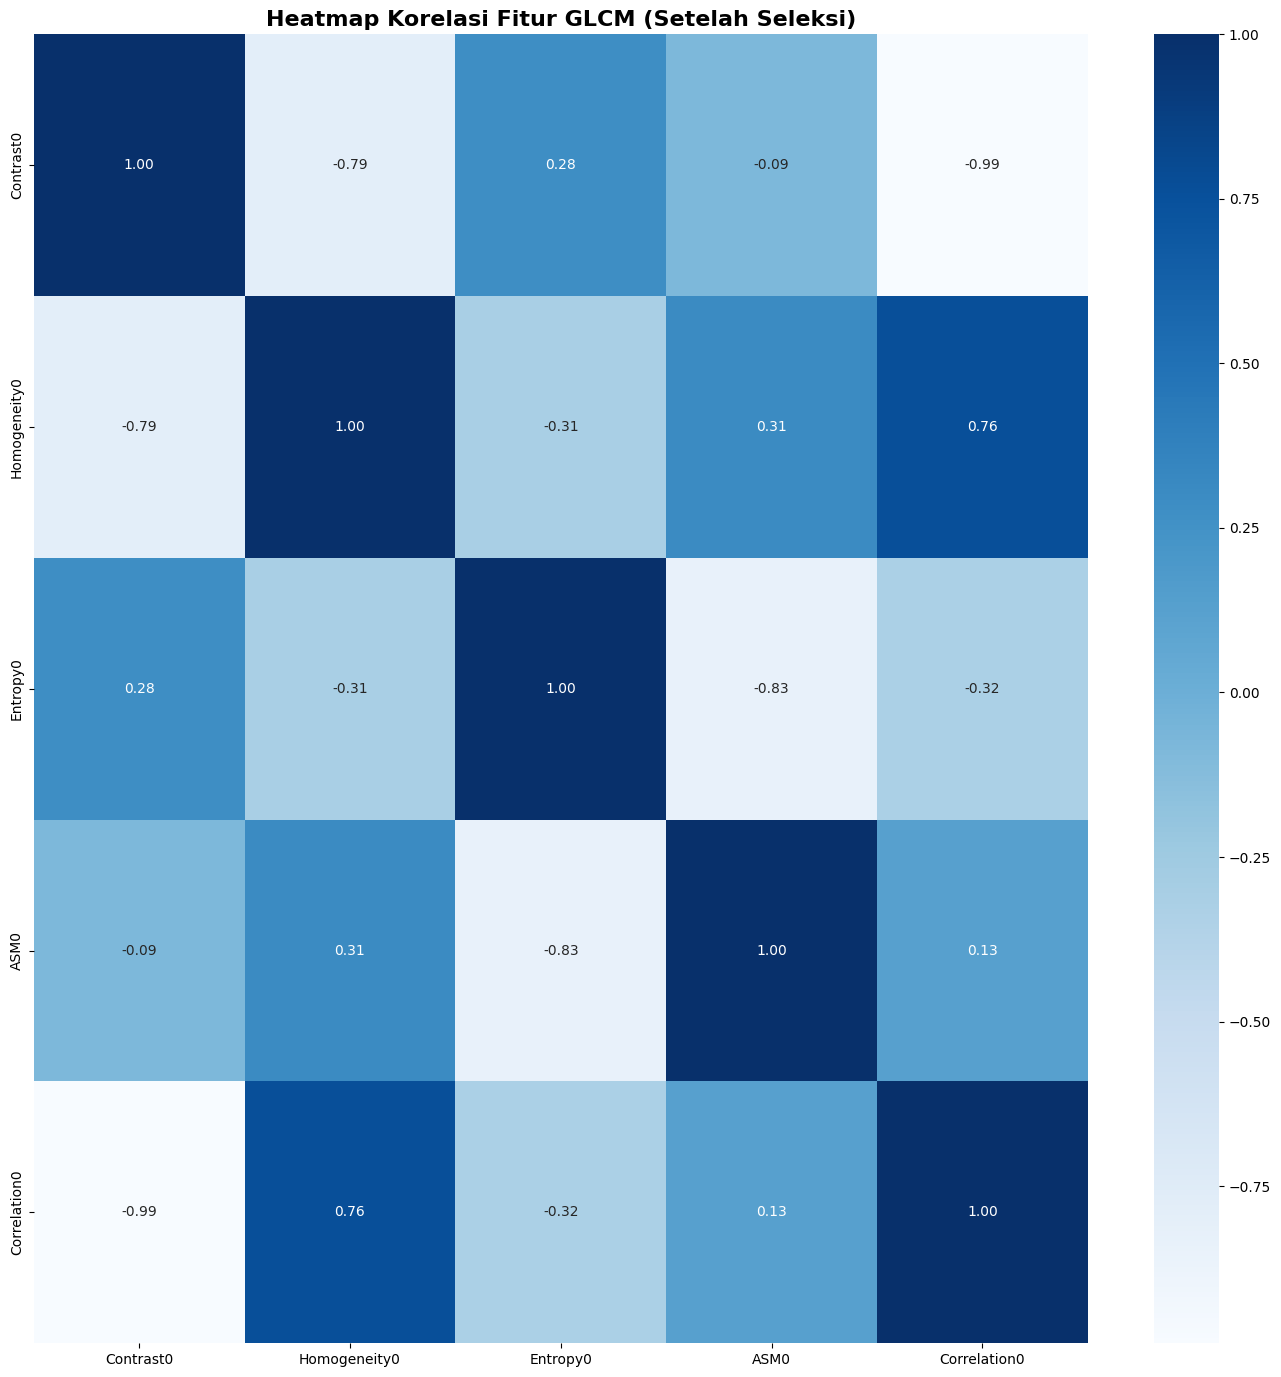

In [ ]:
# Menghitung korelasi
correlation = hasilEkstrak.drop(columns=['Label','Filename']).corr()

# Menyaring fitur yang memiliki korelasi absolut lebih dari 0.95 dengan label
threshold = 0.95 # atur threshold ini untuk menentukan seberapa besar korelasi yang ingin disaring
selectionFeature = []
columns = np.full((correlation.shape[0],), True, dtype=bool)
for i in range(correlation.shape[0]):
	for j in range(i+1, correlation.shape[0]):
		if correlation.iloc[i,j] >= threshold:
			if columns[j]:
				columns[j] = False
select = hasilEkstrak.drop(columns=['Label','Filename']).columns[columns]
x_new = hasilEkstrak[select]
x_new
y = hasilEkstrak['Label']
plt.figure(figsize=(17,17))
sns.heatmap(x_new.corr(), annot=True, cmap='Blues', fmt=".2f")
plt.title('Heatmap Korelasi Fitur GLCM (Setelah Seleksi)', fontsize=16, fontweight='bold')
plt.show()

In [ ]:
# === 1. SPLITTING DATA ===
# ubah bagian test_size sesuai kebutuhan
# 0.3 = 30% data untuk testing (train/test 70/30)
# 0.2 = 20% data untuk testing (train/test 80/20)
X_train, X_test, y_train, y_test = train_test_split(x_new, y, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)

# === 2. FEATURE NORMALIZATION ===
# normalisasi mean std
X_test = (X_test - X_train.mean()) / X_train.std()
X_train = (X_train - X_train.mean()) / X_train.std()

(2400, 5)
(600, 5)


In [ ]:
def generateClassificationReport(y_true, y_pred):
	print(classification_report(y_true, y_pred))
	print(confusion_matrix(y_true, y_pred))
	print('Accuracy:', accuracy_score(y_true, y_pred))

# Define classifiers
rf = RandomForestClassifier(n_estimators=5, random_state=42)
svm = SVC(kernel='rbf', random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)

In [ ]:
# === 1. TRAIN & EVALUATE RANDOM FOREST ===
print("==================================================")
print("              RANDOM FOREST CLASSIFIER            ")
print("==================================================")
rf.fit(X_train, y_train)

print("------Training Set------")
y_pred_train_rf = rf.predict(X_train)
generateClassificationReport(y_train, y_pred_train_rf)

print("\n------Testing Set------")
y_pred_test_rf = rf.predict(X_test)
generateClassificationReport(y_test, y_pred_test_rf)

              RANDOM FOREST CLASSIFIER            
------Training Set------
                             precision    recall  f1-score   support

      Tomato___Early_blight       0.98      0.97      0.98       783
Tomato___Septoria_leaf_spot       0.95      0.97      0.96       803
           Tomato___healthy       0.99      0.97      0.98       814

                   accuracy                           0.97      2400
                  macro avg       0.97      0.97      0.97      2400
               weighted avg       0.97      0.97      0.97      2400

[[763  20   0]
 [ 17 776  10]
 [  0  22 792]]
Accuracy: 0.97125

------Testing Set------
                             precision    recall  f1-score   support

      Tomato___Early_blight       0.82      0.87      0.85       217
Tomato___Septoria_leaf_spot       0.74      0.74      0.74       197
           Tomato___healthy       0.91      0.84      0.87       186

                   accuracy                           0.82       600
  

In [ ]:
# === 2. TRAIN & EVALUATE SVM ===
print("\n==================================================")
print("                   SVM CLASSIFIER                 ")
print("==================================================")
svm.fit(X_train, y_train)

print("------Training Set------")
y_pred_train_svm = svm.predict(X_train)
generateClassificationReport(y_train, y_pred_train_svm)

print("\n------Testing Set------")
y_pred_test_svm = svm.predict(X_test)
generateClassificationReport(y_test, y_pred_test_svm)


                   SVM CLASSIFIER                 
------Training Set------
                             precision    recall  f1-score   support

      Tomato___Early_blight       0.86      0.80      0.83       783
Tomato___Septoria_leaf_spot       0.72      0.76      0.74       803
           Tomato___healthy       0.87      0.89      0.88       814

                   accuracy                           0.81      2400
                  macro avg       0.82      0.81      0.81      2400
               weighted avg       0.82      0.81      0.81      2400

[[623 147  13]
 [101 608  94]
 [  0  93 721]]
Accuracy: 0.8133333333333334

------Testing Set------
                             precision    recall  f1-score   support

      Tomato___Early_blight       0.91      0.84      0.87       217
Tomato___Septoria_leaf_spot       0.77      0.80      0.79       197
           Tomato___healthy       0.89      0.93      0.91       186

                   accuracy                           0.85 

In [ ]:
# === 3. TRAIN & EVALUATE KNN ===
print("\n==================================================")
print("                   KNN CLASSIFIER                 ")
print("==================================================")
knn.fit(X_train, y_train)

print("------Training Set------")
y_pred_train_knn = knn.predict(X_train)
generateClassificationReport(y_train, y_pred_train_knn)

print("\n------Testing Set------")
y_pred_test_knn = knn.predict(X_test)
generateClassificationReport(y_test, y_pred_test_knn)


                   KNN CLASSIFIER                 
------Training Set------
                             precision    recall  f1-score   support

      Tomato___Early_blight       0.88      0.86      0.87       783
Tomato___Septoria_leaf_spot       0.80      0.81      0.81       803
           Tomato___healthy       0.91      0.92      0.91       814

                   accuracy                           0.86      2400
                  macro avg       0.86      0.86      0.86      2400
               weighted avg       0.86      0.86      0.86      2400

[[674 105   4]
 [ 79 653  71]
 [ 11  56 747]]
Accuracy: 0.8641666666666666

------Testing Set------
                             precision    recall  f1-score   support

      Tomato___Early_blight       0.87      0.87      0.87       217
Tomato___Septoria_leaf_spot       0.79      0.78      0.79       197
           Tomato___healthy       0.90      0.91      0.91       186

                   accuracy                           0.85 

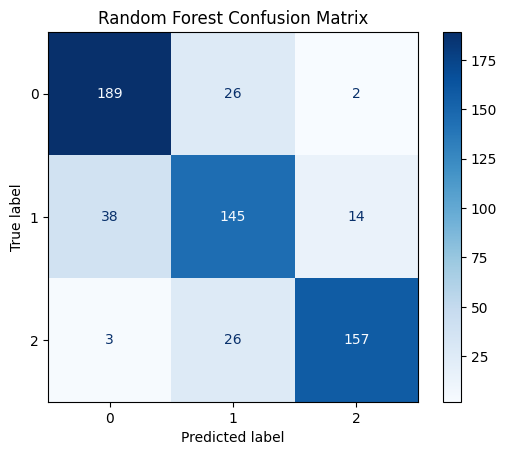

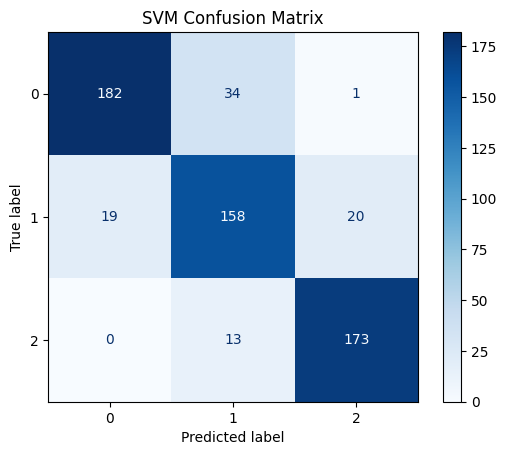

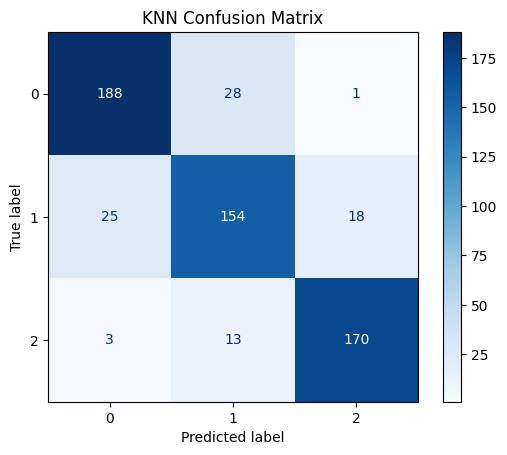

In [ ]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.show()

# Plot confusion matrix for Random Forest
plot_confusion_matrix(y_test, rf.predict(X_test), "Random Forest Confusion Matrix")
# Plot confusion matrix for SVM
plot_confusion_matrix(y_test, svm.predict(X_test), "SVM Confusion Matrix")
# Plot confusion matrix for KNN
plot_confusion_matrix(y_test, knn.predict(X_test), "KNN Confusion Matrix")